# DSM050 Data Visualisation

## Midterm Coursework

**Title:** Global CO₂ Emissions, Economic Development and Energy Sources: An Exploratory Data Visualisation Study

**Student:** Abinaya Ganapathipillai

**Student ID:** 250409387

**Module:** DSM050 Data Visualisation

**Dataset:** Our World in Data (OWID) CO₂ and Greenhouse Gas Emissions Dataset

**Notebook:** Data Preparation, Exploratory Data Analysis and Visualisations

**Date:** 13.07.2026

### Research Questions

**RQ1:** How have global CO₂ emissions changed over time?

**RQ2:** How is economic development related to CO₂ emissions?

**RQ3:** How do different energy sources contribute to global CO₂ emissions?

The notebook is organised so that each research question is answered through relevant preprocessing, exploratory analysis and visualisation.

# 1. Setup

In [1]:
%matplotlib inline

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Consistent visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 9

# Folder for exported figures
os.makedirs("integrated_figures", exist_ok=True)
os.makedirs("integrated_outputs", exist_ok=True)

# 2. Load Dataset

In [2]:
co2_raw = pd.read_csv("owid-co2-data.csv")
codebook = pd.read_csv("owid-co2-codebook.csv")

print(f"Raw dataset shape: {co2_raw.shape}")
print(f"Codebook shape: {codebook.shape}")

co2_raw.head()

Raw dataset shape: (50411, 79)
Codebook shape: (79, 5)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Available Variables
The full list of variables is displayed before variable selection. This helps confirm which indicators are available in the dataset version used for the coursework.

In [3]:
co2_raw.columns.tolist()

['country',
 'year',
 'iso_code',
 'population',
 'gdp',
 'cement_co2',
 'cement_co2_per_capita',
 'co2',
 'co2_growth_abs',
 'co2_growth_prct',
 'co2_including_luc',
 'co2_including_luc_growth_abs',
 'co2_including_luc_growth_prct',
 'co2_including_luc_per_capita',
 'co2_including_luc_per_gdp',
 'co2_including_luc_per_unit_energy',
 'co2_per_capita',
 'co2_per_gdp',
 'co2_per_unit_energy',
 'coal_co2',
 'coal_co2_per_capita',
 'consumption_co2',
 'consumption_co2_per_capita',
 'consumption_co2_per_gdp',
 'cumulative_cement_co2',
 'cumulative_co2',
 'cumulative_co2_including_luc',
 'cumulative_coal_co2',
 'cumulative_flaring_co2',
 'cumulative_gas_co2',
 'cumulative_luc_co2',
 'cumulative_oil_co2',
 'cumulative_other_co2',
 'energy_per_capita',
 'energy_per_gdp',
 'flaring_co2',
 'flaring_co2_per_capita',
 'gas_co2',
 'gas_co2_per_capita',
 'ghg_excluding_lucf_per_capita',
 'ghg_per_capita',
 'land_use_change_co2',
 'land_use_change_co2_per_capita',
 'methane',
 'methane_per_capita',
 

# 3. Dataset Overview
The initial overview checks data types, missing values and descriptive statistics before cleaning. This step is useful because the dataset contains long historical coverage, and some early observations have incomplete economic and population data.

In [4]:
co2_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

In [5]:
co2_raw.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
year,50411.0,1.920349e+03,6.585912e+01,1.750000e+03,1.875000e+03,1.925000e+03,1.975000e+03,2.024000e+03
population,41167.0,6.017294e+07,3.308412e+08,2.150000e+02,3.272140e+05,2.291264e+06,9.986553e+06,8.161973e+09
gdp,15251.0,3.300495e+11,3.086383e+12,4.998000e+07,7.874038e+09,2.743861e+10,1.212627e+11,1.301126e+14
cement_co2,29173.0,7.890109e+00,6.298817e+01,0.000000e+00,0.000000e+00,0.000000e+00,5.240000e-01,1.666885e+03
cement_co2_per_capita,25648.0,6.002558e-02,1.235664e-01,0.000000e+00,0.000000e+00,1.000000e-03,7.700000e-02,2.484000e+00
co2,29384.0,4.202270e+02,1.972092e+03,0.000000e+00,3.810000e-01,5.081000e+00,5.365650e+01,3.859858e+04
co2_growth_abs,27216.0,6.268847e+00,6.219955e+01,-1.928339e+03,-5.000000e-03,4.400000e-02,1.018000e+00,1.804657e+03
co2_growth_prct,26239.0,4.259822e+01,1.721913e+03,-1.000000e+02,-1.070500e+00,3.813000e+00,1.088400e+01,1.808700e+05
co2_including_luc,23796.0,5.441446e+02,2.273282e+03,-8.456000e+01,6.667750e+00,2.812000e+01,1.243033e+02,4.318409e+04
co2_including_luc_growth_abs,23496.0,7.483698e+00,9.951252e+01,-2.298978e+03,-7.275000e-01,1.120000e-01,2.765250e+00,2.614874e+03


## 3.1 Missing Values in the Raw Dataset

Missing values are expected because the dataset covers many countries and historical years. Instead of removing all missing rows immediately, missingness is first explored so that cleaning decisions remain targeted to the research questions.

In [6]:
missing_raw = (
    co2_raw.isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing_raw.columns = ["Variable", "Missing values"]
missing_raw.head(15)

,Variable,Missing values
0,share_global_cumulative_other_co2,48241
1,share_global_other_co2,48241
2,other_co2_per_capita,47752
3,cumulative_other_co2,47157
4,other_industry_co2,47157
5,consumption_co2_per_gdp,45963
6,consumption_co2_per_capita,45768
7,trade_co2,45699
8,trade_co2_share,45699
9,consumption_co2,45358


# 4. Data Cleaning and Pre-processing
Only variables relevant to the research questions are selected. This reduces dimensionality and makes the visual analysis more focused. The selected variables cover emissions, population, GDP and energy-source emissions.

In [7]:
selected_columns = [
    "country",
    "year",
    "iso_code",
    "population",
    "gdp",
    "co2",
    "co2_per_capita",
    "co2_per_gdp",
    "coal_co2",
    "oil_co2",
    "gas_co2",
    "cement_co2",
    "flaring_co2",
    "primary_energy_consumption",
    "energy_per_capita",
    "energy_per_gdp"
]

co2 = co2_raw[selected_columns].copy()

co2.head()

,country,year,iso_code,population,gdp,co2,co2_per_capita,co2_per_gdp,coal_co2,oil_co2,gas_co2,cement_co2,flaring_co2,primary_energy_consumption,energy_per_capita,energy_per_gdp
0,Afghanistan,1750,AFG,2802560.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


## 4.1 Data Type Conversion and Missing CO₂ Values

The year variable is treated as an integer. Observations without total CO₂ emissions are removed because total CO₂ is the main outcome variable used in the visual analysis.

In [8]:
co2["year"] = co2["year"].astype(int)

numeric_columns = [
    "population",
    "gdp",
    "co2",
    "co2_per_capita",
    "co2_per_gdp",
    "coal_co2",
    "oil_co2",
    "gas_co2",
    "cement_co2",
    "flaring_co2",
    "primary_energy_consumption",
    "energy_per_capita",
    "energy_per_gdp"
]

for column in numeric_columns:
    co2[column] = pd.to_numeric(co2[column], errors="coerce")

co2 = co2.dropna(subset=["co2"]).drop_duplicates()

print(f"Cleaned dataset shape: {co2.shape}")

Cleaned dataset shape: (29384, 16)


## 4.2 Feature Engineering

GDP per capita is not directly available in this dataset version, so it is engineered by dividing GDP by population. This supports fairer comparisons between countries of different population sizes.

In [9]:
co2["gdp_per_capita"] = co2["gdp"] / co2["population"]

# Separate actual countries from aggregates such as World, Asia and OECD.
# Three-letter ISO codes identify country-level observations in this dataset.
country_df = co2[
    co2["iso_code"].notna() &
    (co2["iso_code"].str.len() == 3)
].copy()

world = co2[co2["country"] == "World"].copy()

print(f"Country-level dataset shape: {country_df.shape}")
print(f"World dataset shape: {world.shape}")

Country-level dataset shape: (23408, 17)
World dataset shape: (275, 17)


### 4.2.1 Preprocessing Transparency

The following output distinguishes removal of observations without CO₂ data from the later country-level filter. This avoids presenting regional aggregates as if they were missing or invalid records.

In [10]:
rows_before_cleaning = len(co2_raw)
rows_after_co2_filter = len(co2)
country_rows = len(country_df)
aggregate_rows_excluded = rows_after_co2_filter - country_rows
country_retention_rate = country_rows / rows_before_cleaning * 100

print(f"Raw observations                    : {rows_before_cleaning:,}")
print(f"Observations after CO₂/duplicate filter: {rows_after_co2_filter:,}")
print(f"Country-level observations          : {country_rows:,}")
print(f"Aggregate observations excluded     : {aggregate_rows_excluded:,}")
print(f"Country-level retention rate        : {country_retention_rate:.1f}%")

Raw observations                    : 50,411
Observations after CO₂/duplicate filter: 29,384
Country-level observations          : 23,408
Aggregate observations excluded     : 5,976
Country-level retention rate        : 46.4%


## 4.3 Final Missing Value Check

The final missing value check shows which selected variables still contain gaps. These are not all removed because different research questions use different subsets of variables.

In [11]:
missing_selected = (
    co2.isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing_selected.columns = ["Variable", "Missing values"]
missing_selected

,Variable,Missing values
0,energy_per_gdp,21608
1,energy_per_capita,18842
2,primary_energy_consumption,18804
3,gdp_per_capita,14719
4,gdp,14691
5,flaring_co2,13610
6,co2_per_gdp,11856
7,gas_co2,11237
8,cement_co2,7586
9,coal_co2,7459


## 4.4 Figure 1: Missing Values Visualisation

A horizontal bar chart was selected because it makes it easy to compare missing-value counts across variables with long names. This supports transparent preprocessing by showing where gaps remain after variable selection.

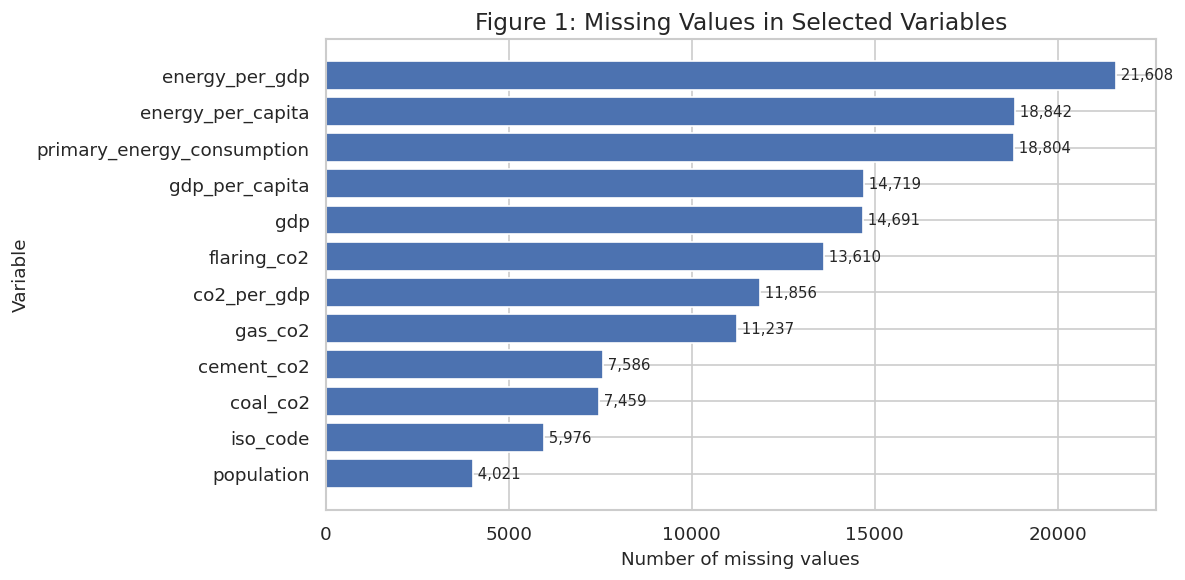

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_data = missing_selected.head(12).sort_values("Missing values")

ax.barh(plot_data["Variable"], plot_data["Missing values"])
ax.set_title("Figure 1: Missing Values in Selected Variables")
ax.set_xlabel("Number of missing values")
ax.set_ylabel("Variable")

for index, value in enumerate(plot_data["Missing values"]):
    ax.text(value, index, f" {value:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("integrated_figures/01_missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

The chart shows that missing values are concentrated in selected economic and energy-related variables. These gaps are expected in historical international datasets, so later visualisations use relevant subsets rather than deleting all rows with any missing value.

# 5. Dataset Summary
The summary table provides a compact overview of the cleaned country-level dataset used for analysis.

In [13]:
summary_table = pd.DataFrame({
    "Metric": [
        "Original observations",
        "Country-level observations",
        "Variables analysed",
        "Countries",
        "First year",
        "Latest year",
        "Average CO₂ emissions (Mt)",
        "Median CO₂ emissions (Mt)"
    ],
    "Value": [
        f"{len(co2_raw):,}",
        f"{len(country_df):,}",
        country_df.shape[1],
        country_df["country"].nunique(),
        int(country_df["year"].min()),
        int(country_df["year"].max()),
        f"{country_df['co2'].mean():,.2f}",
        f"{country_df['co2'].median():,.2f}"
    ]
})

summary_table

,Metric,Value
0,Original observations,"50,411"
1,Country-level observations,"23,408"
2,Variables analysed,17
3,Countries,215
4,First year,1750
5,Latest year,2024
6,Average CO₂ emissions (Mt),77.03
7,Median CO₂ emissions (Mt),2.78


# 6. Exploratory Data Analysis
This section explores the structure of the cleaned dataset before answering the research questions. Univariate charts are used first to understand the distribution and coverage of key variables, followed by multivariate charts that compare emissions with economic and energy indicators.

## 6.1 Figure 2: Distribution of Country-Level CO₂ Emissions

A histogram was selected because it provides an effective overview of the distribution and skewness of country-level CO₂ emissions before further analysis. A logarithmic scale is used because emissions vary greatly between countries.

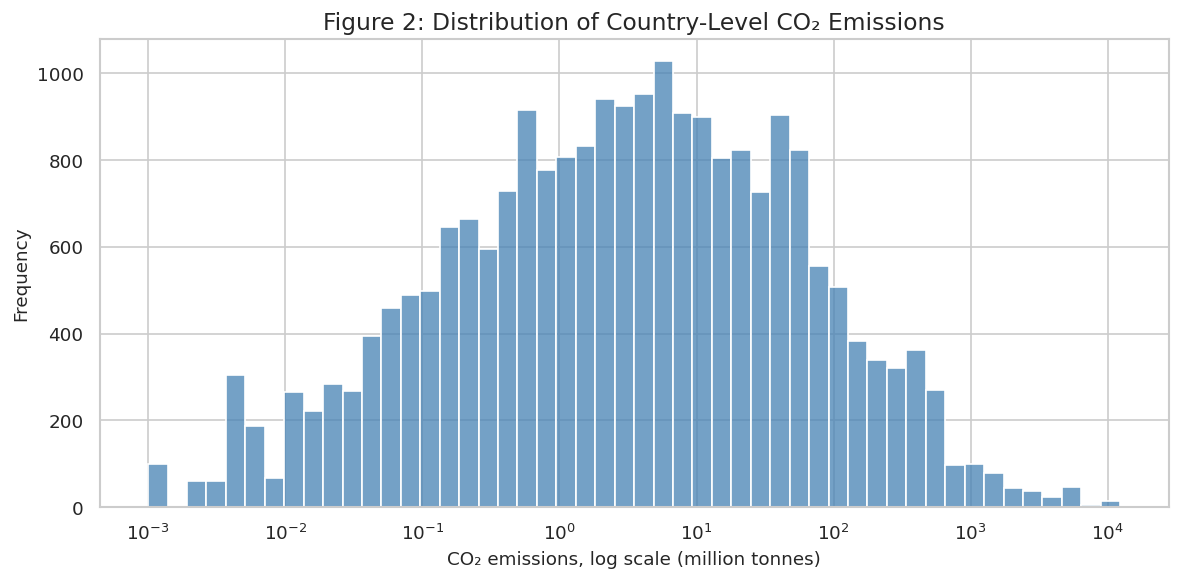

In [14]:
co2_positive = country_df[country_df["co2"] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=co2_positive,
    x="co2",
    bins=50,
    log_scale=True,
    ax=ax,
    color="steelblue"
)

ax.set_title("Figure 2: Distribution of Country-Level CO₂ Emissions")
ax.set_xlabel("CO₂ emissions, log scale (million tonnes)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("integrated_figures/02_distribution_co2_log.png", dpi=300, bbox_inches="tight")
plt.show()

The distribution is highly positively skewed, with most countries producing comparatively low CO₂ emissions while a small number of countries contribute extremely large emission volumes.

## 6.2 Figure 3: Distribution of Country-Level CO₂ Emissions (Box Plot)

A box plot was added to complement the histogram because it highlights spread and outliers more directly. This is useful for CO₂ data because country-level emissions are highly uneven.

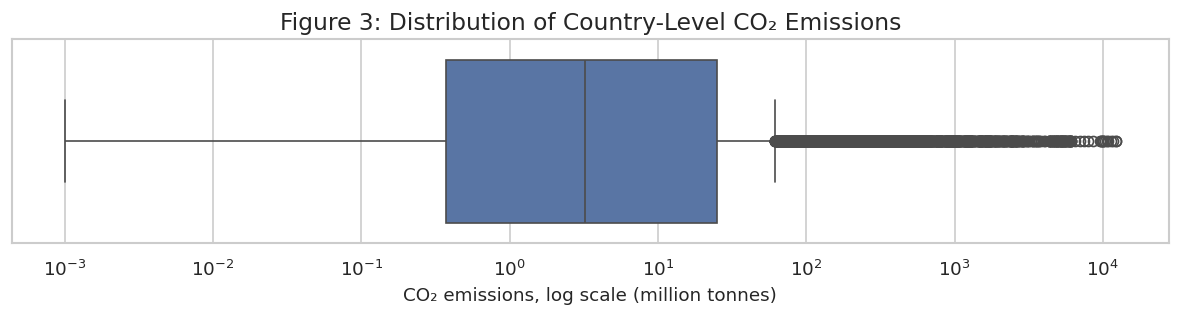

In [15]:
fig, ax = plt.subplots(figsize=(10, 2.8))

sns.boxplot(
    x=co2_positive["co2"],
    ax=ax
)

ax.set_xscale("log")
ax.set_title("Figure 3: Distribution of Country-Level CO₂ Emissions")
ax.set_xlabel("CO₂ emissions, log scale (million tonnes)")

plt.tight_layout()
plt.savefig("integrated_figures/03_boxplot_co2.png", dpi=300, bbox_inches="tight")
plt.show()

The box plot confirms that country-level CO₂ emissions are highly right-skewed. Most countries produce relatively low emissions, while a small number of major economies appear as extreme outliers, justifying the use of logarithmic scales in later analyses.

## 6.3 Figure 4: Country Coverage Over Time

A line chart was selected because it shows how data availability changes across years. This is important because limited early coverage may affect interpretation of long-term country-level patterns.

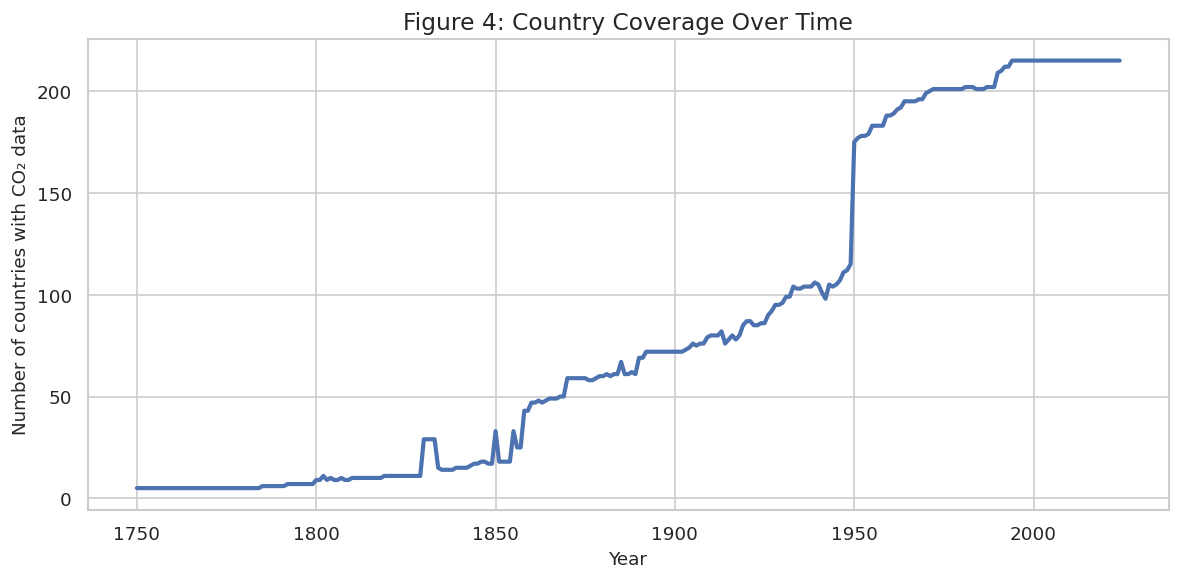

In [16]:
coverage = (
    country_df.dropna(subset=["co2"])
    .groupby("year")["country"]
    .nunique()
    .reset_index(name="Number of countries")
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(coverage["year"], coverage["Number of countries"], linewidth=2.5)

ax.set_title("Figure 4: Country Coverage Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Number of countries with CO₂ data")

plt.tight_layout()
plt.savefig("integrated_figures/04_country_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

Country coverage increases steadily over time, indicating improved global reporting and data availability in recent decades. Early historical comparisons should therefore be interpreted with more caution.

# 7. RQ1 – Global Emission Trends
This section examines the long-term development of global CO₂ emissions and identifies the largest current emitting countries.

## 7.1 Figure 5: Global CO₂ Emissions Over Time

A line chart was selected because it is well suited to showing continuous change over time. The latest available year is annotated to draw attention to the current scale of global emissions.

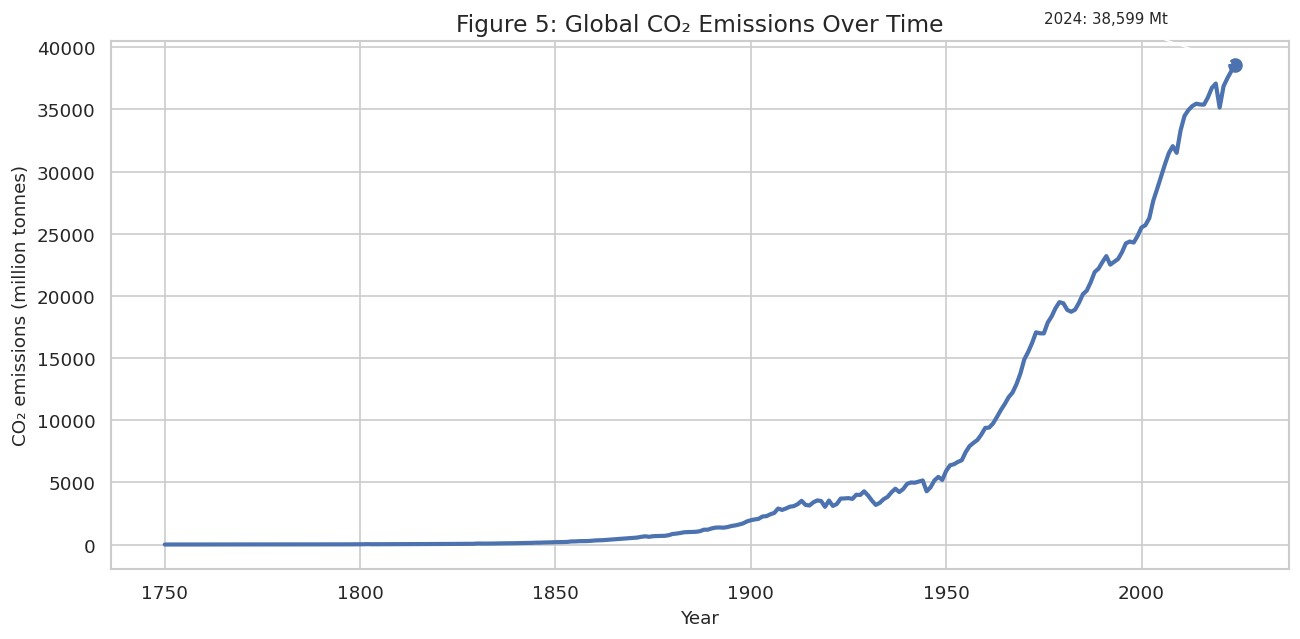

In [17]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(world["year"], world["co2"], linewidth=2.5)

latest_year = int(world["year"].max())
latest_global_co2 = world.loc[world["year"] == latest_year, "co2"].iloc[0]

ax.scatter(latest_year, latest_global_co2, s=60, zorder=3)
ax.annotate(
    f"{latest_year}: {latest_global_co2:,.0f} Mt",
    xy=(latest_year, latest_global_co2),
    xytext=(-115, 25),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=1),
    fontsize=9
)

ax.set_title("Figure 5: Global CO₂ Emissions Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("CO₂ emissions (million tonnes)")

plt.tight_layout()
plt.savefig("integrated_figures/05_global_co2_trend.png", dpi=300, bbox_inches="tight")
plt.show()

Global CO₂ emissions increased gradually in the early period before accelerating strongly after the mid-twentieth century, reflecting industrialisation, population growth and expanding fossil-fuel consumption.

## 7.2 Figure 6: Global Emissions by Complete Decade

Aggregating emissions by complete decade provides a clearer view of long-term growth and reduces year-to-year noise. The incomplete current decade is excluded so that every bar represents the same ten-year period.

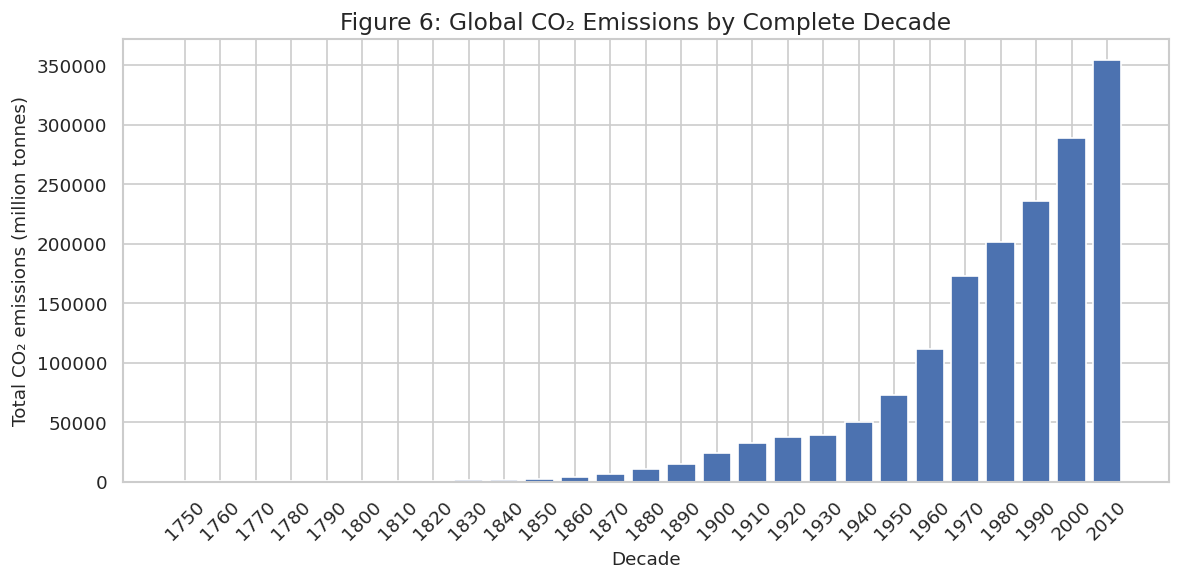

In [18]:
world_decade = world.copy()
world_decade["decade"] = (world_decade["year"] // 10) * 10

latest_complete_decade = (int(world_decade["year"].max()) // 10) * 10 - 10

decade_emissions = (
    world_decade[world_decade["decade"] <= latest_complete_decade]
    .groupby("decade")["co2"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(decade_emissions["decade"].astype(str), decade_emissions["co2"])

ax.set_title("Figure 6: Global CO₂ Emissions by Complete Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Total CO₂ emissions (million tonnes)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("integrated_figures/06_world_decade_emissions.png", dpi=300, bbox_inches="tight")
plt.show()

Total emissions increased substantially across successive complete decades. Excluding the incomplete current decade prevents a shorter period from being compared directly with full ten-year totals.

## 7.3 Figure 7: Top 10 Emitting Countries

A horizontal bar chart was selected because it allows country names and emission values to be read clearly. This supports comparison between the largest emitting countries in the latest available year.

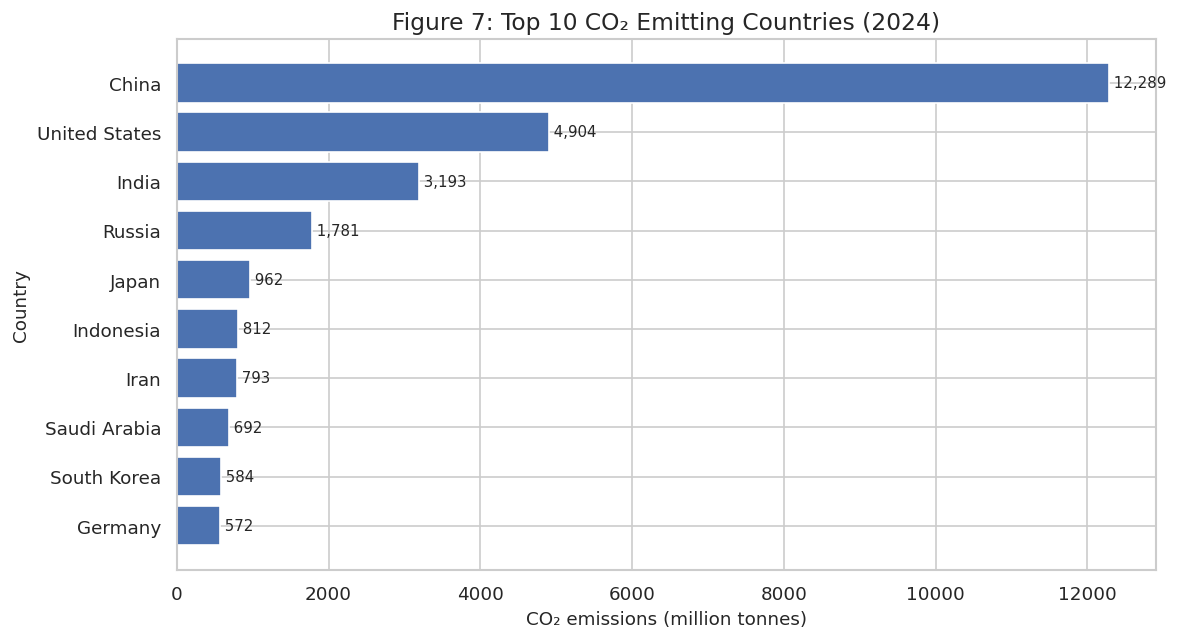

In [19]:
latest_country_year = int(country_df["year"].max())

top10_emitters = (
    country_df[country_df["year"] == latest_country_year]
    .dropna(subset=["co2"])
    .nlargest(10, "co2")
    .sort_values("co2")
)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.barh(top10_emitters["country"], top10_emitters["co2"])

ax.set_title(f"Figure 7: Top 10 CO₂ Emitting Countries ({latest_country_year})")
ax.set_xlabel("CO₂ emissions (million tonnes)")
ax.set_ylabel("Country")

for index, value in enumerate(top10_emitters["co2"]):
    ax.text(value, index, f" {value:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("integrated_figures/07_top10_emitters_latest.png", dpi=300, bbox_inches="tight")
plt.show()

A relatively small number of countries account for a disproportionately large share of current global CO₂ emissions, highlighting inequality in national emission contributions.

## 7.4 Figure 8: Trends for Major Emitters

A multi-line chart was selected to compare how emissions have changed for the largest emitters over time. Keeping the legend in the upper-left corner supports consistency across the notebook.

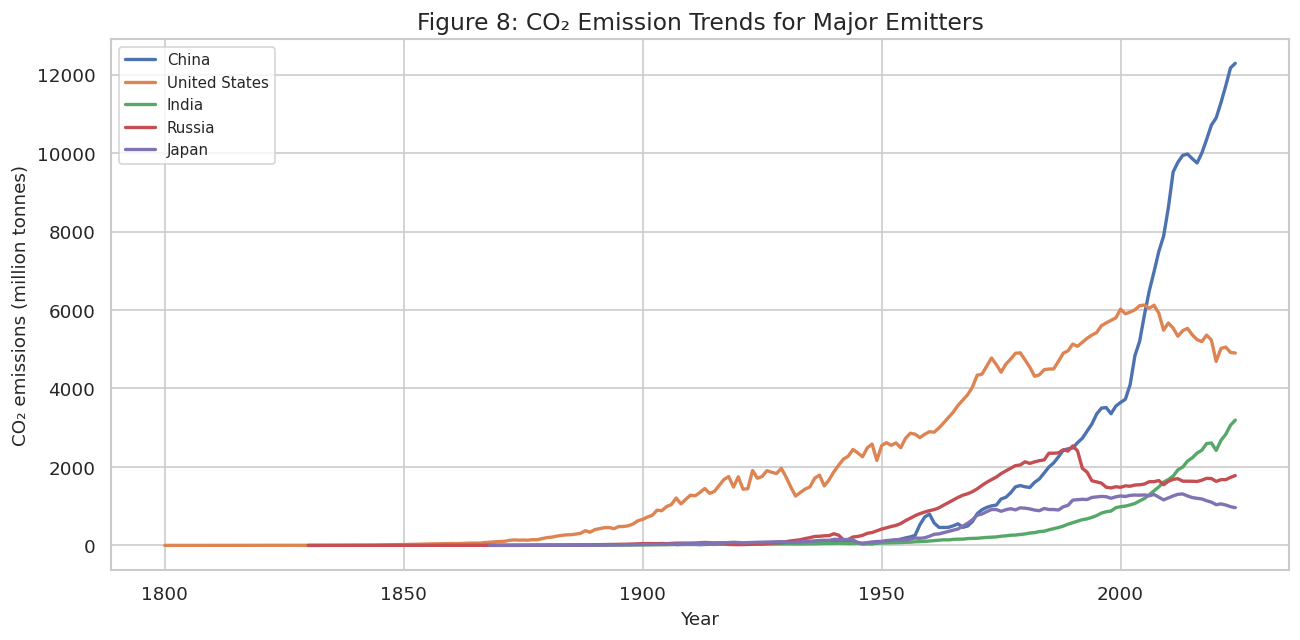

In [20]:
top5_countries = top10_emitters.sort_values("co2", ascending=False).head(5)["country"].tolist()

top5_trends = country_df[
    country_df["country"].isin(top5_countries)
].copy()

fig, ax = plt.subplots(figsize=(11, 5.5))

for country in top5_countries:
    data = top5_trends[top5_trends["country"] == country]
    ax.plot(data["year"], data["co2"], linewidth=2, label=country)

ax.set_title("Figure 8: CO₂ Emission Trends for Major Emitters")
ax.set_xlabel("Year")
ax.set_ylabel("CO₂ emissions (million tonnes)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("integrated_figures/08_top5_emitter_trends.png", dpi=300, bbox_inches="tight")
plt.show()

The major emitters follow different historical pathways. Some countries show long-term growth over many decades, while others show sharper recent increases linked to rapid economic development.

### RQ1 Observation

Global CO₂ emissions show a strong long-term increase, especially after industrialisation and the mid-twentieth century. The latest-year comparison shows that emissions are concentrated among a small number of countries, which means global reductions depend strongly on actions by the largest emitters.

# 8. RQ2 – Economic Development and Emissions
This section analyses whether economic development is associated with higher CO₂ emissions. Logarithmic scales are used because GDP and emissions are highly skewed and differ substantially between countries.

## 8.1 Figure 9: GDP and CO₂ Emissions

A scatter plot was selected because it shows the relationship between two numerical variables. The log-log scale makes patterns more visible where countries differ greatly in economic size and emissions.

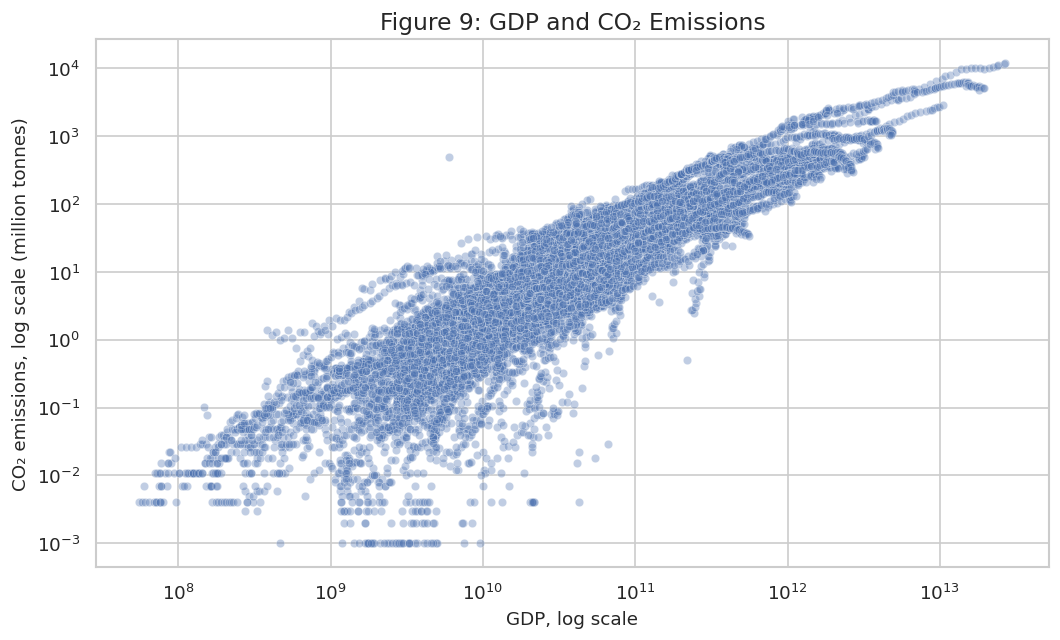

In [21]:
gdp_data = country_df.dropna(subset=["gdp", "co2", "population", "gdp_per_capita", "co2_per_capita"]).copy()
gdp_data = gdp_data[(gdp_data["gdp"] > 0) & (gdp_data["co2"] > 0)]

fig, ax = plt.subplots(figsize=(9, 5.5))

sns.scatterplot(
    data=gdp_data,
    x="gdp",
    y="co2",
    alpha=0.35,
    s=25,
    ax=ax
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Figure 9: GDP and CO₂ Emissions")
ax.set_xlabel("GDP, log scale")
ax.set_ylabel("CO₂ emissions, log scale (million tonnes)")

plt.tight_layout()
plt.savefig("integrated_figures/09_gdp_vs_co2_log.png", dpi=300, bbox_inches="tight")
plt.show()

Countries with larger economies generally emit more CO₂, although considerable variation exists. This suggests that economic output is important, but it does not fully explain national emission levels.

## 8.2 Figure 10: GDP per Capita and CO₂ per Capita

A latest-year bubble scatter plot compares per-capita economic output with per-capita emissions while bubble area represents population. Restricting the chart to one year avoids mixing repeated country observations from different historical periods.

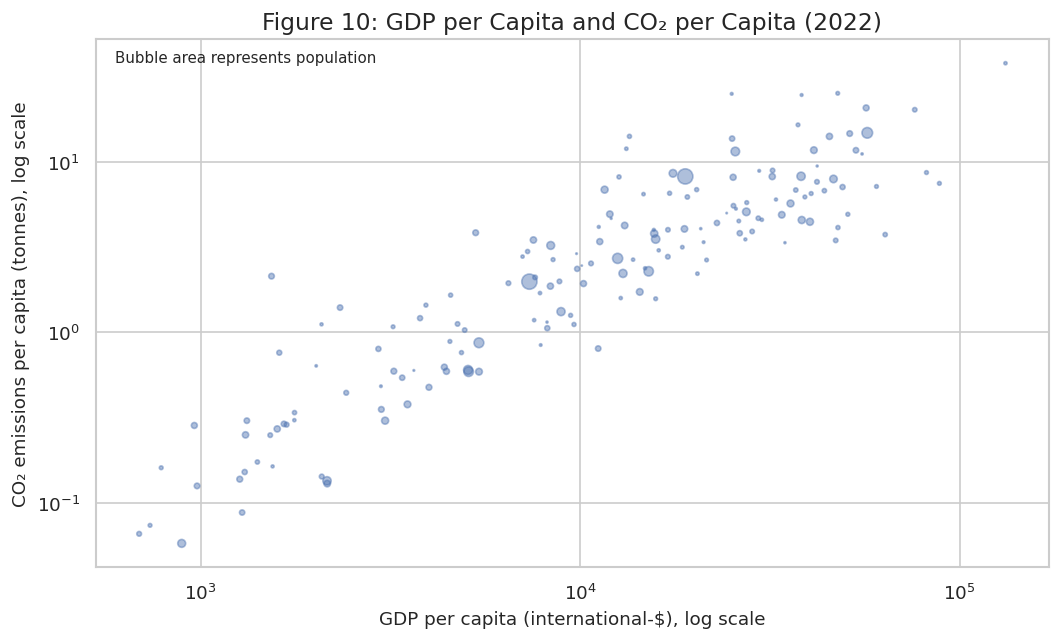

In [22]:
latest_gdp_year = int(gdp_data["year"].max())

latest_gdp = (
    gdp_data[gdp_data["year"] == latest_gdp_year]
    .dropna(subset=["gdp_per_capita", "co2_per_capita", "population"])
    .copy()
)

latest_gdp = latest_gdp[
    (latest_gdp["gdp_per_capita"] > 0) &
    (latest_gdp["co2_per_capita"] > 0)
]

bubble_size = np.sqrt(latest_gdp["population"]) / 450

fig, ax = plt.subplots(figsize=(9, 5.5))

scatter = ax.scatter(
    latest_gdp["gdp_per_capita"],
    latest_gdp["co2_per_capita"],
    s=bubble_size,
    alpha=0.45
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title(f"Figure 10: GDP per Capita and CO₂ per Capita ({latest_gdp_year})")
ax.set_xlabel("GDP per capita (international-$), log scale")
ax.set_ylabel("CO₂ emissions per capita (tonnes), log scale")

ax.text(
    0.02, 0.98,
    "Bubble area represents population",
    transform=ax.transAxes,
    ha="left", va="top", fontsize=9
)

plt.tight_layout()
plt.savefig("integrated_figures/10_gdp_per_capita_vs_co2_per_capita.png", dpi=300, bbox_inches="tight")
plt.show()

Higher-income countries often show higher per-capita emissions, although the relationship is not uniform. Population size, energy mix and national policy differences create substantial variation.

## 8.3 Figure 11: Economic Correlation Matrix

A correlation heatmap was selected because colour intensity enables rapid comparison of relationships between multiple numerical variables. This supports the interpretation of economic and emissions indicators together.

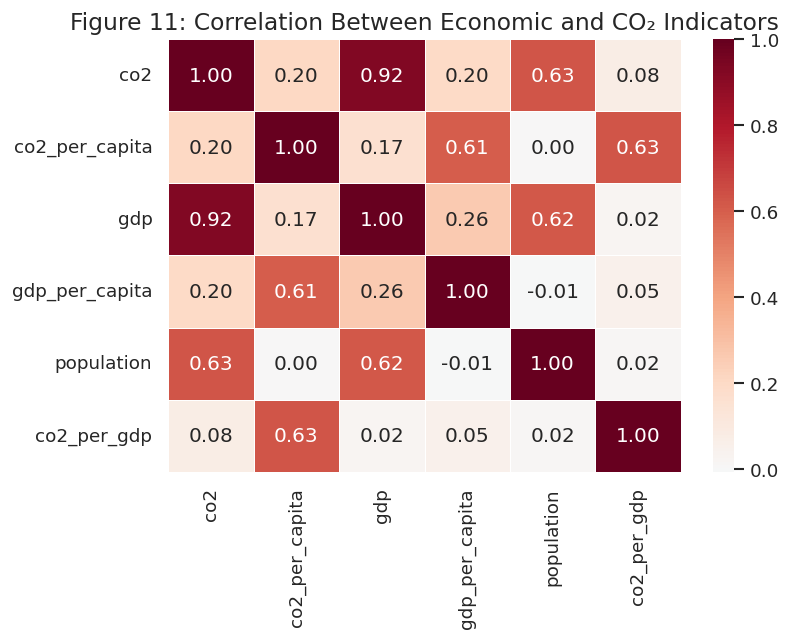

In [23]:
economic_columns = [
    "co2",
    "co2_per_capita",
    "gdp",
    "gdp_per_capita",
    "population",
    "co2_per_gdp"
]

economic_corr = gdp_data[economic_columns].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))

sns.heatmap(
    economic_corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Figure 11: Correlation Between Economic and CO₂ Indicators")

plt.tight_layout()
plt.savefig("integrated_figures/11_economic_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

GDP, population and total CO₂ emissions show strong positive relationships, while per-capita and intensity-based indicators provide a more nuanced view of economic development and emissions.

In [24]:
correlation_summary = pd.DataFrame({
    "Relationship": [
        "GDP and total CO₂",
        "GDP per capita and CO₂ per capita",
        "Population and total CO₂"
    ],
    "Correlation": [
        gdp_data["gdp"].corr(gdp_data["co2"]),
        gdp_data["gdp_per_capita"].corr(gdp_data["co2_per_capita"]),
        gdp_data["population"].corr(gdp_data["co2"])
    ]
})

correlation_summary

,Relationship,Correlation
0,GDP and total CO₂,0.924881
1,GDP per capita and CO₂ per capita,0.605009
2,Population and total CO₂,0.628248


### RQ2 Observation

The analysis shows a positive relationship between economic activity and CO₂ emissions. Total GDP is associated with total emissions, while GDP per capita is also related to CO₂ per capita. However, the spread of points shows that economic development does not translate into emissions in the same way for every country, suggesting that energy mix, efficiency and policy differences also matter.

# 9. RQ3 – Energy Sources and Emissions
This section examines the contribution of coal, oil, gas, cement and flaring to global CO₂ emissions. The analysis uses the World aggregate because the research question focuses on global energy-source patterns.

In [25]:
energy_sources = ["coal_co2", "oil_co2", "gas_co2", "cement_co2", "flaring_co2"]

energy = world[["year"] + energy_sources].copy()
energy = energy.dropna(subset=energy_sources, how="all")

energy.head()

,year,coal_co2,oil_co2,gas_co2,cement_co2,flaring_co2
49511,1750,9.306,NaN,NaN,NaN,NaN
49512,1751,9.407,NaN,NaN,NaN,NaN
49513,1752,9.505,NaN,NaN,NaN,NaN
49514,1753,9.610,NaN,NaN,NaN,NaN
49515,1754,9.734,NaN,NaN,NaN,NaN


## 9.1 Figure 12: Global CO₂ Emissions by Energy Source

A stacked area chart was selected because it shows both total emissions growth and the contribution of individual sources over time. This helps identify which energy sources dominate global emissions.

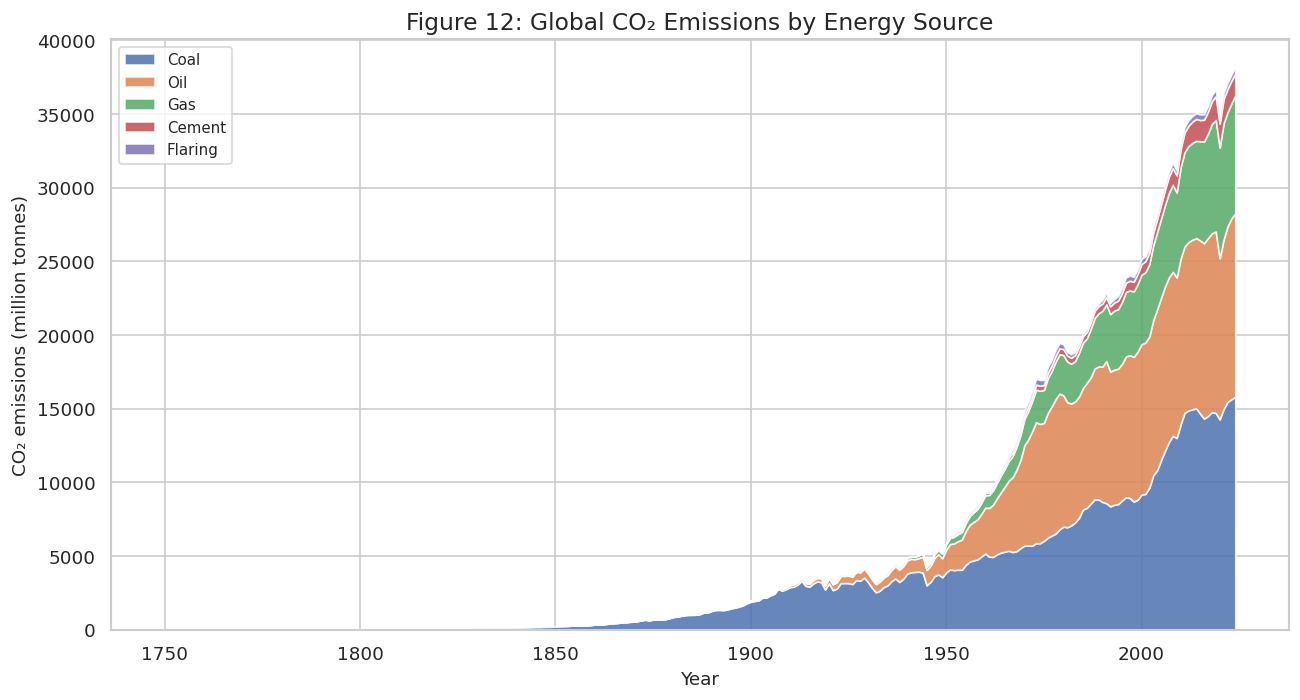

In [26]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.stackplot(
    energy["year"],
    energy["coal_co2"],
    energy["oil_co2"],
    energy["gas_co2"],
    energy["cement_co2"],
    energy["flaring_co2"],
    labels=["Coal", "Oil", "Gas", "Cement", "Flaring"],
    alpha=0.85
)

ax.set_title("Figure 12: Global CO₂ Emissions by Energy Source")
ax.set_xlabel("Year")
ax.set_ylabel("CO₂ emissions (million tonnes)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("integrated_figures/12_energy_source_stacked_area.png", dpi=300, bbox_inches="tight")
plt.show()

Coal, oil and gas dominate global CO₂ emissions. Coal remains especially important across much of the historical period, while gas emissions increase strongly in more recent decades.

## 9.2 Figure 13: Energy Source Trends

A line chart was selected to separate energy sources and make their individual growth patterns easier to compare. This complements the stacked area chart by reducing visual overlap.

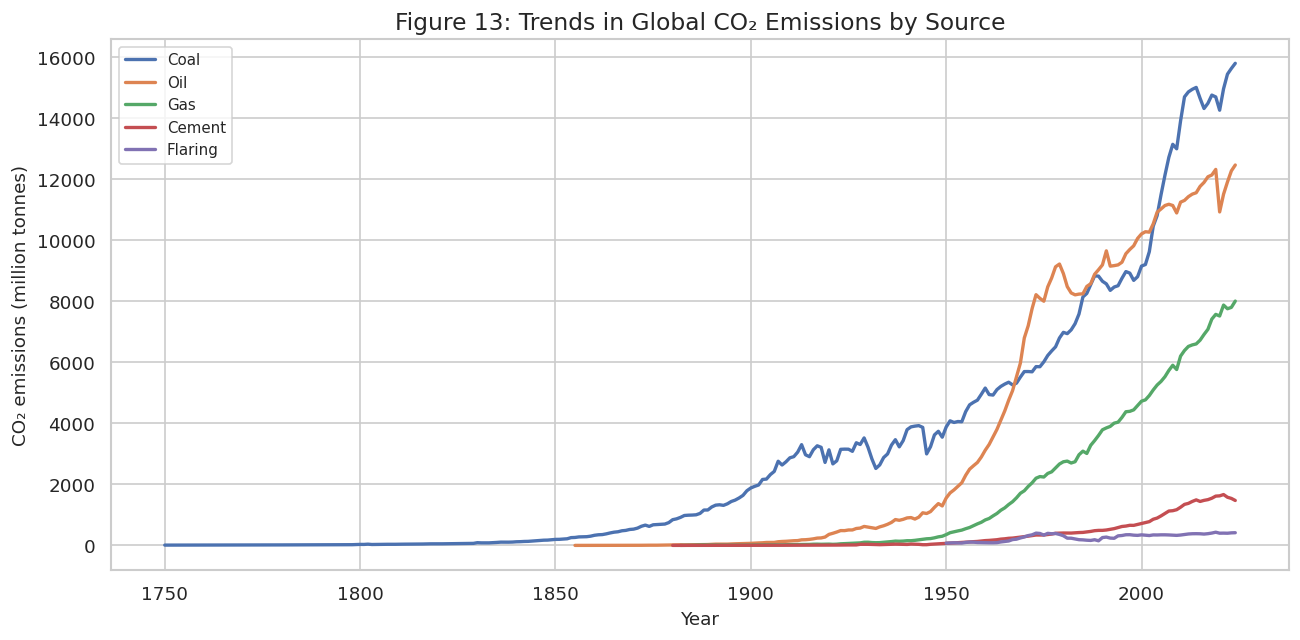

In [27]:
fig, ax = plt.subplots(figsize=(11, 5.5))

source_labels = {
    "coal_co2": "Coal",
    "oil_co2": "Oil",
    "gas_co2": "Gas",
    "cement_co2": "Cement",
    "flaring_co2": "Flaring"
}

for source, label in source_labels.items():
    ax.plot(energy["year"], energy[source], linewidth=2, label=label)

ax.set_title("Figure 13: Trends in Global CO₂ Emissions by Source")
ax.set_xlabel("Year")
ax.set_ylabel("CO₂ emissions (million tonnes)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("integrated_figures/13_energy_source_line_trends.png", dpi=300, bbox_inches="tight")
plt.show()

Coal, oil and gas all show sustained long-term growth, while cement and flaring contribute smaller proportions of total emissions.

## 9.3 Figure 14: Latest-Year Energy Source Comparison

A horizontal bar chart was selected to compare the latest available emissions from each source. Value labels are added to make the chart easier to interpret at a glance.

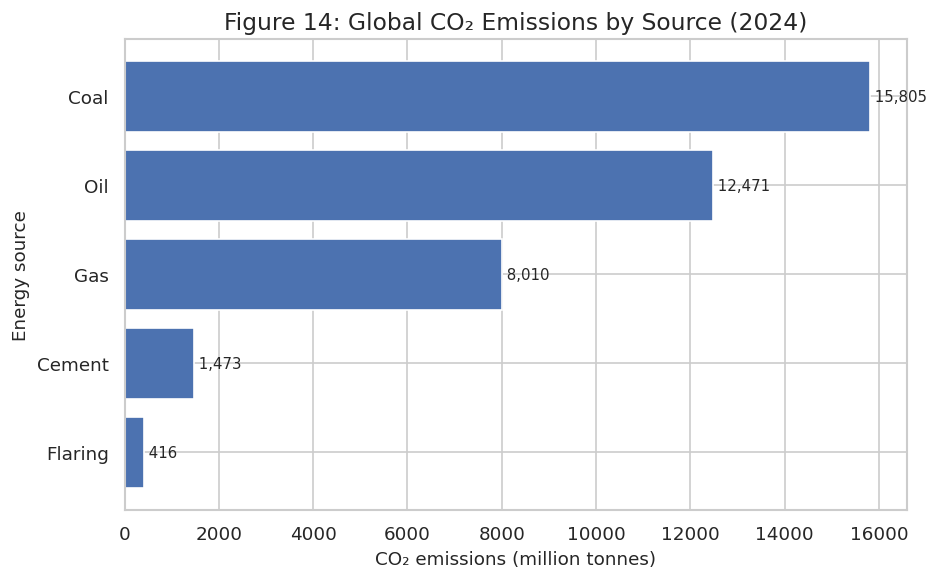

In [28]:
latest_energy_year = int(energy["year"].max())

latest_energy = (
    energy[energy["year"] == latest_energy_year]
    .melt(id_vars="year", var_name="Energy source", value_name="CO₂")
)

latest_energy["Energy source"] = (
    latest_energy["Energy source"]
    .str.replace("_co2", "", regex=False)
    .str.title()
)

latest_energy = latest_energy.sort_values("CO₂")

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(latest_energy["Energy source"], latest_energy["CO₂"])

ax.set_title(f"Figure 14: Global CO₂ Emissions by Source ({latest_energy_year})")
ax.set_xlabel("CO₂ emissions (million tonnes)")
ax.set_ylabel("Energy source")

for index, value in enumerate(latest_energy["CO₂"]):
    ax.text(value, index, f" {value:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("integrated_figures/14_latest_energy_source_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Coal contributes the largest volume of emissions in the latest available year, followed by oil and natural gas. Cement and flaring remain comparatively smaller contributors.

## 9.4 Figure 15. Energy Source Share by Complete Decade

A percentage stacked bar chart shows how the composition of emissions changes over time. Only complete decades are included so that percentage comparisons are based on equal-length periods.

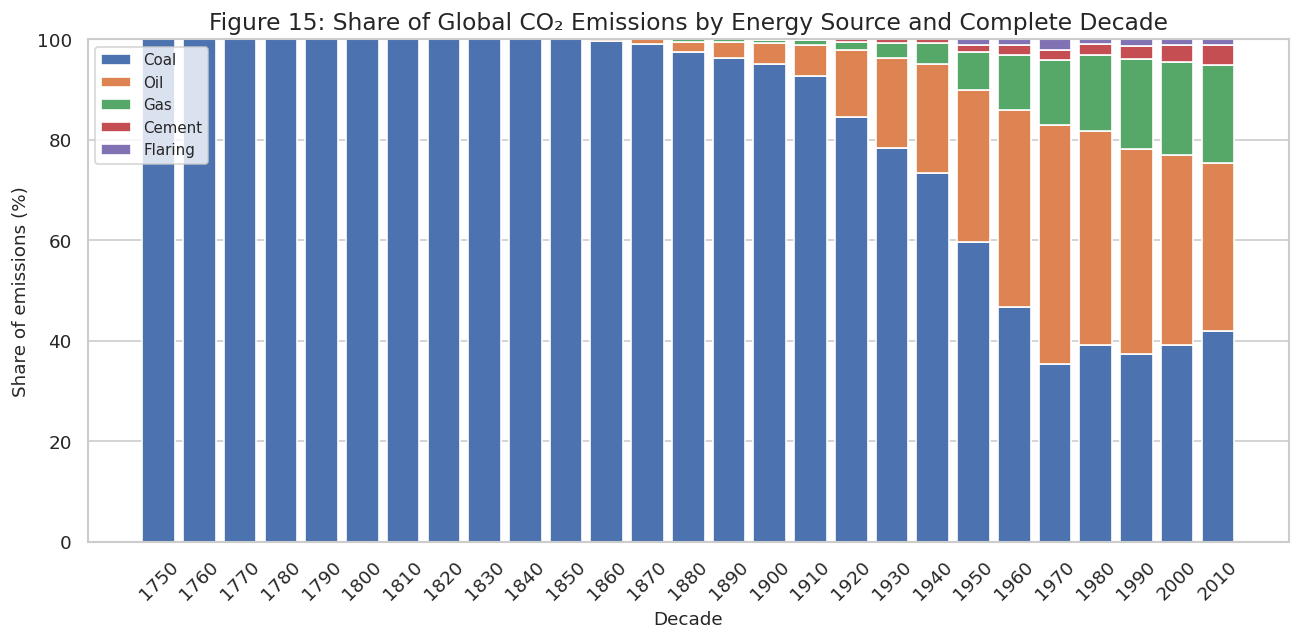

In [29]:
energy_share = energy.copy()
energy_share["decade"] = (energy_share["year"] // 10) * 10

latest_complete_decade = (int(energy_share["year"].max()) // 10) * 10 - 10

energy_decade = (
    energy_share[energy_share["decade"] <= latest_complete_decade]
    .groupby("decade")[energy_sources]
    .sum()
    .reset_index()
)

energy_decade_share = energy_decade.copy()
energy_totals = energy_decade_share[energy_sources].sum(axis=1)

for source in energy_sources:
    energy_decade_share[source] = energy_decade_share[source] / energy_totals * 100

fig, ax = plt.subplots(figsize=(11, 5.5))

bottom = np.zeros(len(energy_decade_share))

for source, label in source_labels.items():
    ax.bar(
        energy_decade_share["decade"].astype(str),
        energy_decade_share[source],
        bottom=bottom,
        label=label
    )
    bottom += energy_decade_share[source].values

ax.set_title("Figure 15: Share of Global CO₂ Emissions by Energy Source and Complete Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Share of emissions (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("integrated_figures/15_energy_source_share_by_decade.png", dpi=300, bbox_inches="tight")
plt.show()

Although fossil fuels remain dominant, the relative contribution of natural gas has increased over time. The percentage view shows changes in the emissions mix more clearly than absolute values alone.

### RQ3 Observation

Coal remains the dominant source of global CO₂ emissions across much of the period. Oil and gas also increase substantially, reflecting growing global energy demand. Cement and flaring contribute smaller shares, but they remain relevant because emissions are linked not only to energy use but also to industrial production.

# 10. Dashboard
The dashboard provides an integrated summary of the three research questions. It is designed for policymakers and environmental analysts who require a concise overview of long-term emission trends, national contributions, the relationship between economic development and emissions, and the role of energy sources.

The layout uses information hierarchy by placing the global trend and top emitters first, followed by latest-year economic comparison and energy-source trends.

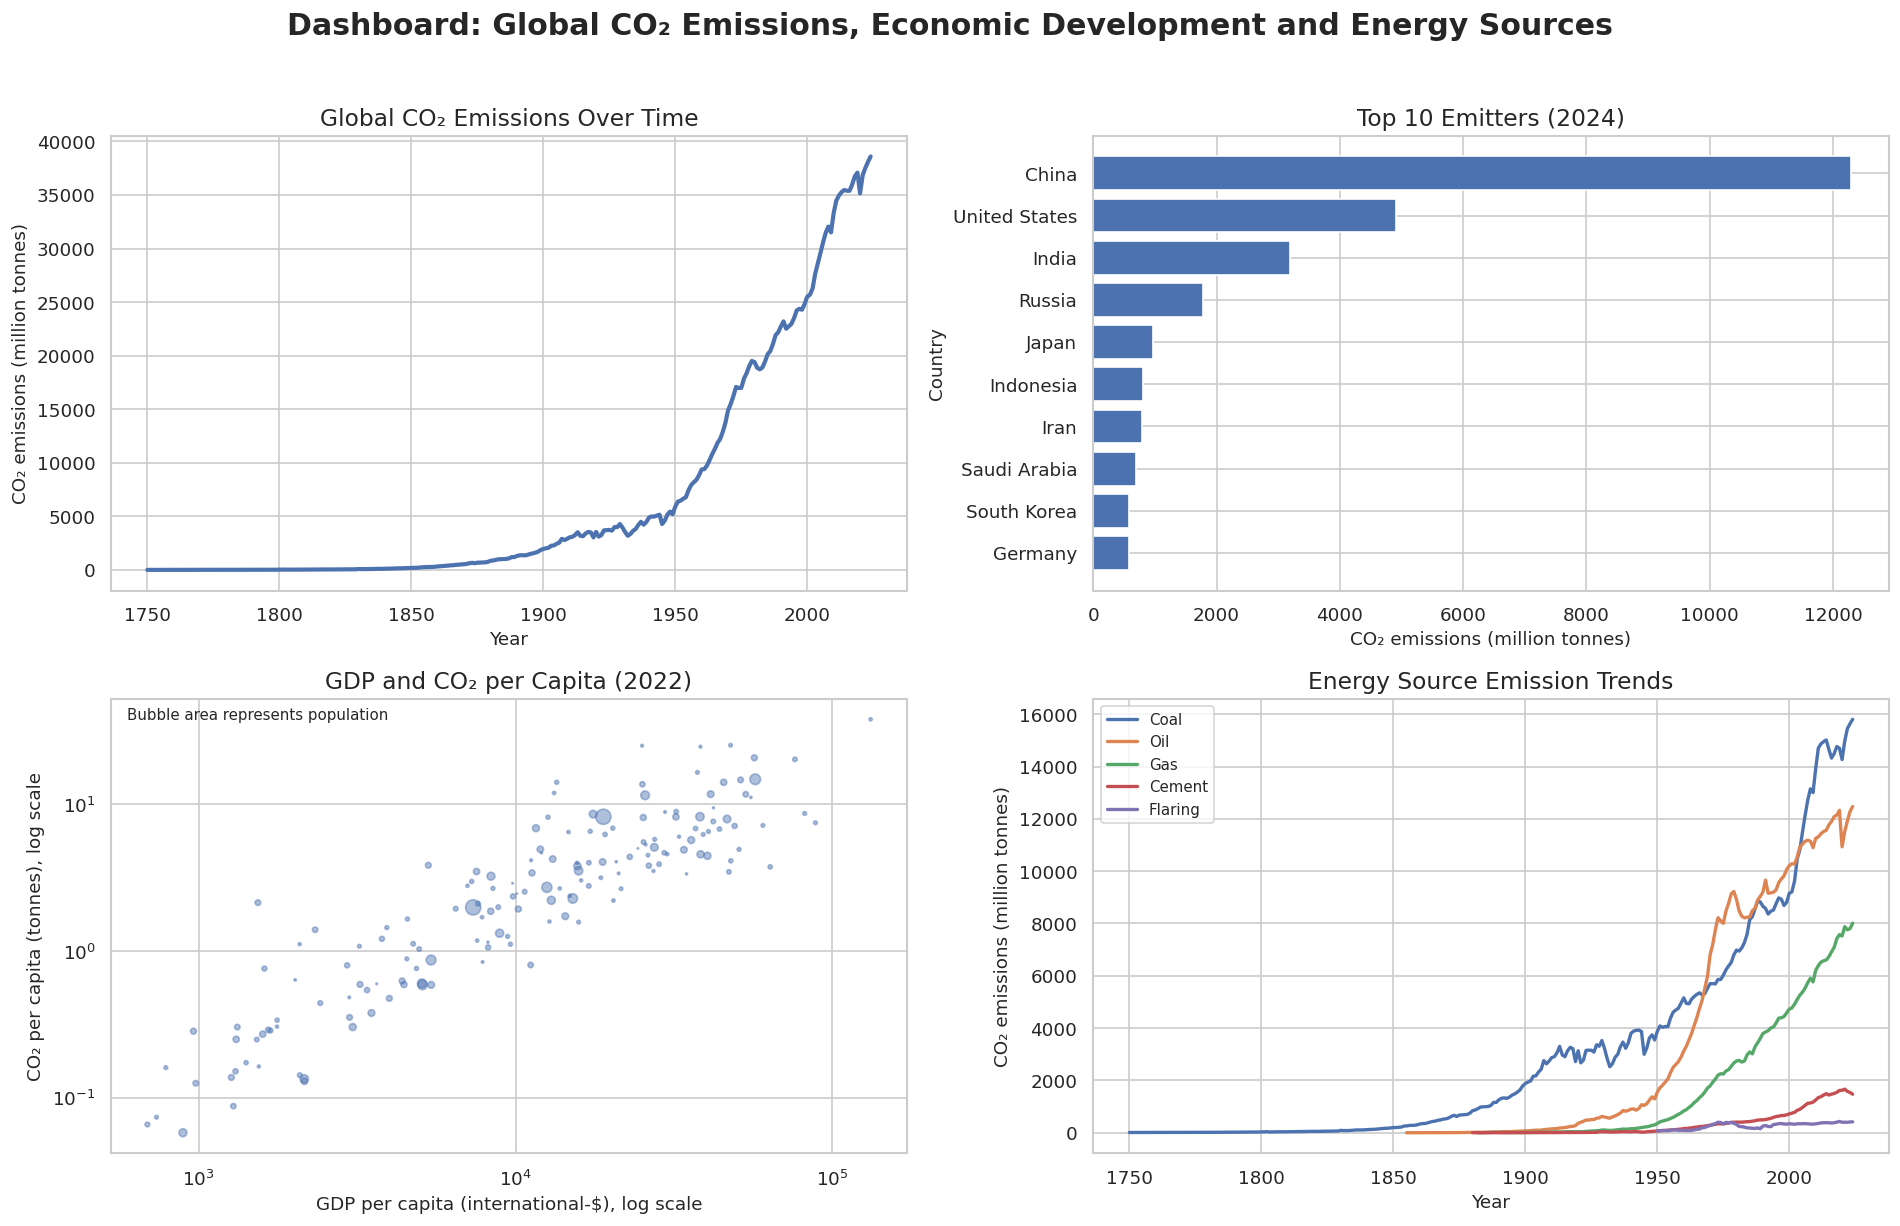

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Global trend
axes[0, 0].plot(world["year"], world["co2"], linewidth=2.5)
axes[0, 0].set_title("Global CO₂ Emissions Over Time")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("CO₂ emissions (million tonnes)")

# 2. Top 10 emitters
dashboard_top10 = top10_emitters.copy()
axes[0, 1].barh(dashboard_top10["country"], dashboard_top10["co2"])
axes[0, 1].set_title(f"Top 10 Emitters ({latest_country_year})")
axes[0, 1].set_xlabel("CO₂ emissions (million tonnes)")
axes[0, 1].set_ylabel("Country")

# 3. Latest-year GDP per capita vs CO₂ per capita
axes[1, 0].scatter(
    latest_gdp["gdp_per_capita"],
    latest_gdp["co2_per_capita"],
    s=bubble_size,
    alpha=0.45
)
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title(f"GDP and CO₂ per Capita ({latest_gdp_year})")
axes[1, 0].set_xlabel("GDP per capita (international-$), log scale")
axes[1, 0].set_ylabel("CO₂ per capita (tonnes), log scale")
axes[1, 0].text(
    0.02, 0.98,
    "Bubble area represents population",
    transform=axes[1, 0].transAxes,
    ha="left", va="top", fontsize=9
)

# 4. Energy-source trends
for source, label in source_labels.items():
    axes[1, 1].plot(energy["year"], energy[source], linewidth=2, label=label)

axes[1, 1].set_title("Energy Source Emission Trends")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("CO₂ emissions (million tonnes)")
axes[1, 1].legend(loc="upper left")

fig.suptitle(
    "Dashboard: Global CO₂ Emissions, Economic Development and Energy Sources",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.savefig("integrated_figures/16_static_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

The dashboard summarises the main findings at a glance: emissions have increased over time, current emissions are concentrated among major economies, GDP and CO₂ are positively associated, and fossil-fuel sources dominate global emissions.

# 11. Export Key Tables
The most important tables are exported as CSV files so they can be used in the report appendix or GitHub repository if required.

In [31]:
summary_table.to_csv("integrated_outputs/summary_table.csv", index=False)
top10_emitters.sort_values("co2", ascending=False).to_csv("integrated_outputs/top10_emitters_latest.csv", index=False)
correlation_summary.to_csv("integrated_outputs/correlation_summary.csv", index=False)
latest_energy.sort_values("CO₂", ascending=False).to_csv("integrated_outputs/latest_energy_sources.csv", index=False)

print("Key tables exported successfully.")

Key tables exported successfully.


# 12. Final Summary
This notebook cleaned and prepared the OWID CO₂ dataset, explored key variables, and produced visualisations for three research questions. The analysis shows that global CO₂ emissions have increased substantially over time, that economic activity is positively associated with emissions, and that coal, oil and gas remain the dominant contributors to global CO₂ emissions.

These findings provide evidence that economic growth and fossil-fuel dependence remain closely associated with global CO₂ emissions, although substantial differences exist between countries, time periods and energy sources. The exported figures and tables can be used directly in the final report.

### 13. References

**Dataset:**

Our World in Data. (2025). CO₂ and Greenhouse Gas Emissions Dataset. Available at: https://ourworldindata.org/co2-and-greenhouse-gas-emissions

**Visualisation guidance:**

Kelleher, C. and Wagener, T. (2011). Ten guidelines for effective data visualization in scientific publications. Environmental Modelling & Software, 26(6), pp. 822–827.

Qin, X., Luo, Y., Tang, N. and Li, G. (2020). Making data visualization more efficient and effective: a survey. The VLDB Journal, 29, pp. 93–117.

Lavanya, A. et al. (2023). Assessing the performance of Python data visualization libraries: a review. International Journal of Computer Engineering Research Trends, 10(1), pp. 28–39.

McKinney, W. (2010). Data structures for statistical computing in Python. Proceedings of the 9th Python in Science Conference, 56–61.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95.

Waskom, M. L. (2021). seaborn: Statistical data visualization. Journal of Open Source Software, 6(60), 3021.

Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array programming with NumPy. Nature, 585, 357–362.

**AI use declaration**

- OpenAI (2026) ChatGPT (GPT-5.1): Used to support notebook organisation, wording refinement, debugging guidance and visualisation improvement suggestions.

- Grammarly (2026): Used to check grammar, spelling, punctuation, and improve the clarity and readability of written explanations.

*AI-generated suggestions were used as guidance only. All code, analysis, interpretations, visualisations, and written explanations included in this submission were reviewed, adapted, and integrated by me. I independently implemented, tested, and verified all code and interpreted all results before including them in the final submission.*

I confirm that all submitted work has been independently verified by me for accuracy, academic integrity, and appropriateness, and that the final submission represents my own understanding and work.